# Tut 12

`INTC.csv` includes monthly closing prices of Intel Corporate (pt ) from Nov/2001 to Oct/2022

In [1]:
%reset -f

In [2]:
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn           as sns
import numpy             as np
import statsmodels.api   as sm

from datetime                    import datetime
from statsmodels.tsa.stattools   import adfuller
from statsmodels.tsa.arima.model import ARIMA
#from pmdarima.arima              import AutoARIMA
from arch                        import arch_model

### Load Data

In [3]:
df = pd.read_csv("INTC.csv")

In [4]:
df.index = pd.date_range(start='2000-11', periods=264, freq='MS')

In [5]:
pd.plotting.register_matplotlib_converters()
sns.mpl.rc('figure',figsize=(16, 6))
pd.set_option('display.float_format', lambda x: '%.2f' % x)

(a) Let $r_t$ denote monthly return of INTC, i.e., $r_t = \frac{p_t}{p{_t−1} − 1}$. Draw the time series plot
of $r_t$ and test its stationarity.

In [6]:
df['Return'] = df['Close'] / df['Close'].shift(1) - 1

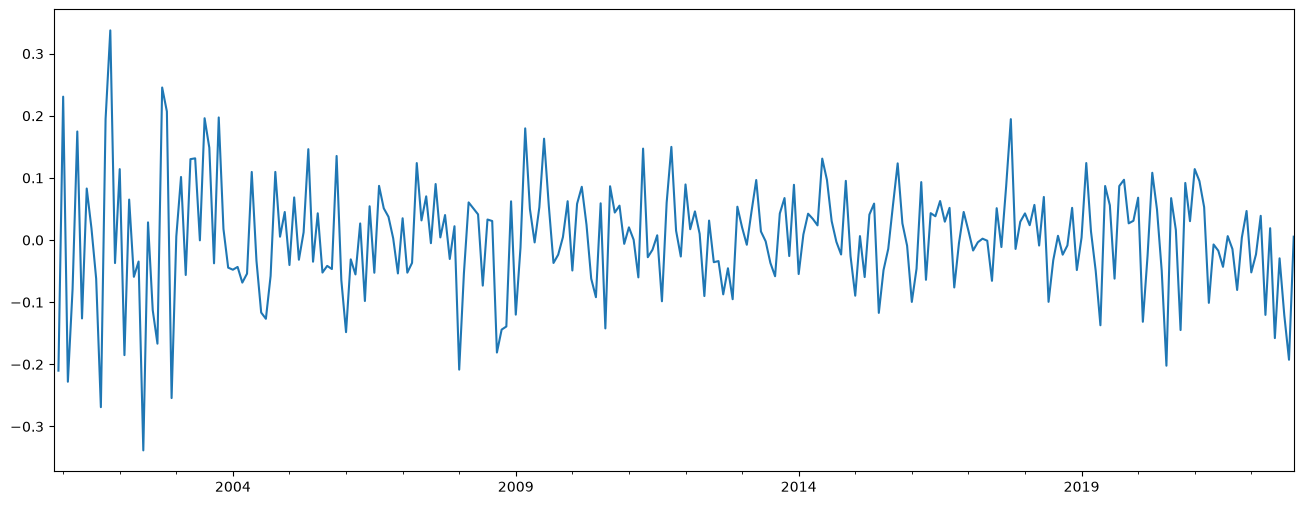

In [7]:
df['Return'].plot()
plt.show()

In [8]:
X = df['Return'].dropna().values

In [9]:
result1=adfuller(X,regression='c',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result1[0], result1[1], result1[2]))

 ADF statistic: -16.886, 
 p-value: 0.000, 
 critical value: {'1%': np.float64(-3.455558114028747), '5%': np.float64(-2.872635586277424), '10%': np.float64(-2.572682677000175)}


In [10]:
result2=adfuller(X,regression='ct',autolag='BIC',regresults=True,store=True)
out = ' ADF statistic: {0:0.3f}, \n p-value: {1:0.3f}, \n critical value: {2}'
print(out.format(result2[0], result2[1], result2[2]))

 ADF statistic: -16.866, 
 p-value: 0.000, 
 critical value: {'1%': np.float64(-3.993745412883642), '5%': np.float64(-3.4273814105122966), '10%': np.float64(-3.1369771257480235)}


(b) Find and plot ACF of $r_t$ and $r_t^2$ . Can you see volatility clustering? Apply the Ljung-Box test and interpret your finding.

In [11]:
df['Return2'] = np.square(df['Close'])

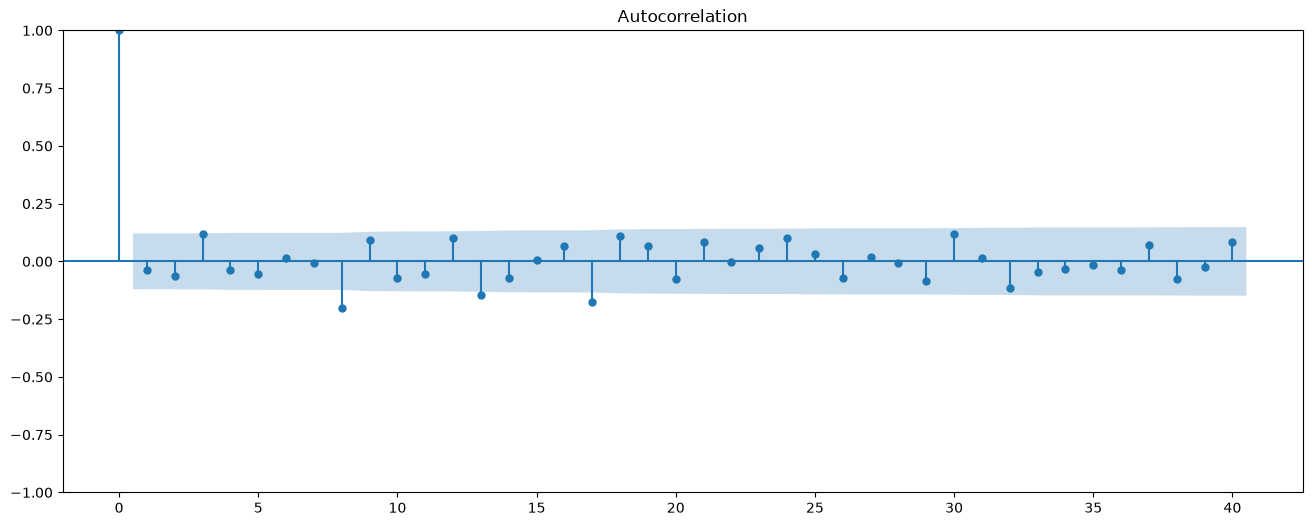

In [12]:
sm.graphics.tsa.plot_acf(df['Return'].dropna().values.squeeze(), lags=40)
plt.show()

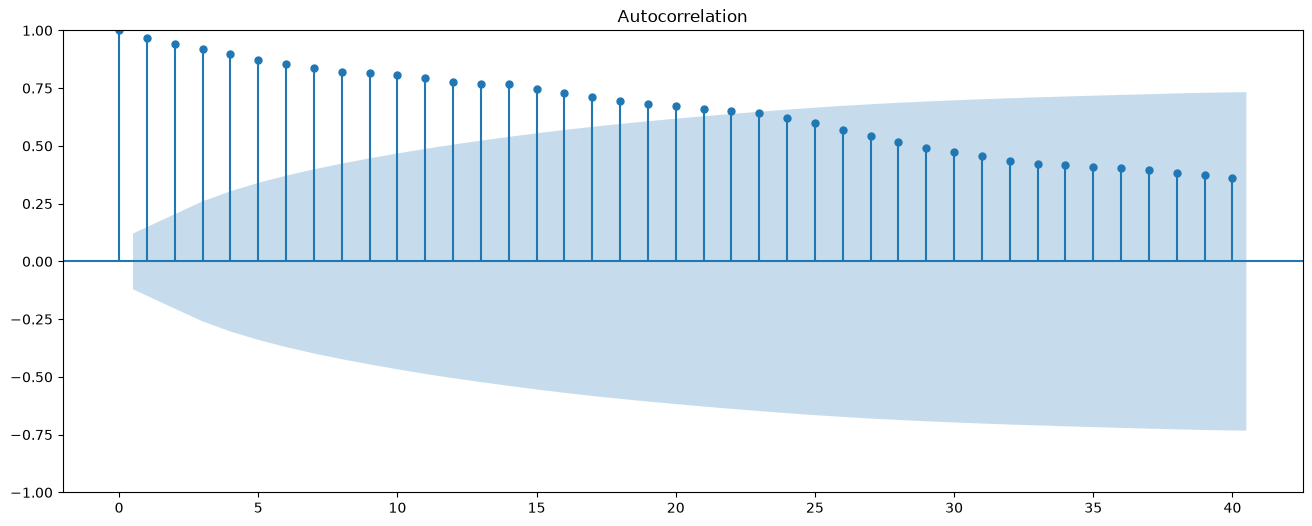

In [13]:
sm.graphics.tsa.plot_acf(df['Return2'].dropna().values.squeeze(), lags=40)
plt.show()

In [14]:
sm.stats.acorr_ljungbox(X, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,21.44,0.02


In [15]:
sm.stats.acorr_ljungbox(df['Return2'].dropna(), lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,2077.00,0.00


(c) Find an appropriate $ARMA(p,q)$ for $r_t$ and estimate the mean equation. What does it imply?

In [16]:
mod = ARIMA(X, order=(2,0,2))
res = mod.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  263
Model:                 ARIMA(2, 0, 2)   Log Likelihood                 267.384
Date:                Thu, 20 Aug 2026   AIC                           -522.768
Time:                        22:11:19   BIC                           -501.335
Sample:                             0   HQIC                          -514.154
                                - 263                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0028      0.005      0.518      0.605      -0.008       0.013
ar.L1         -0.9264      0.015    -61.445      0.000      -0.956      -0.897
ar.L2         -0.9888      0.009   -115.740      0.0

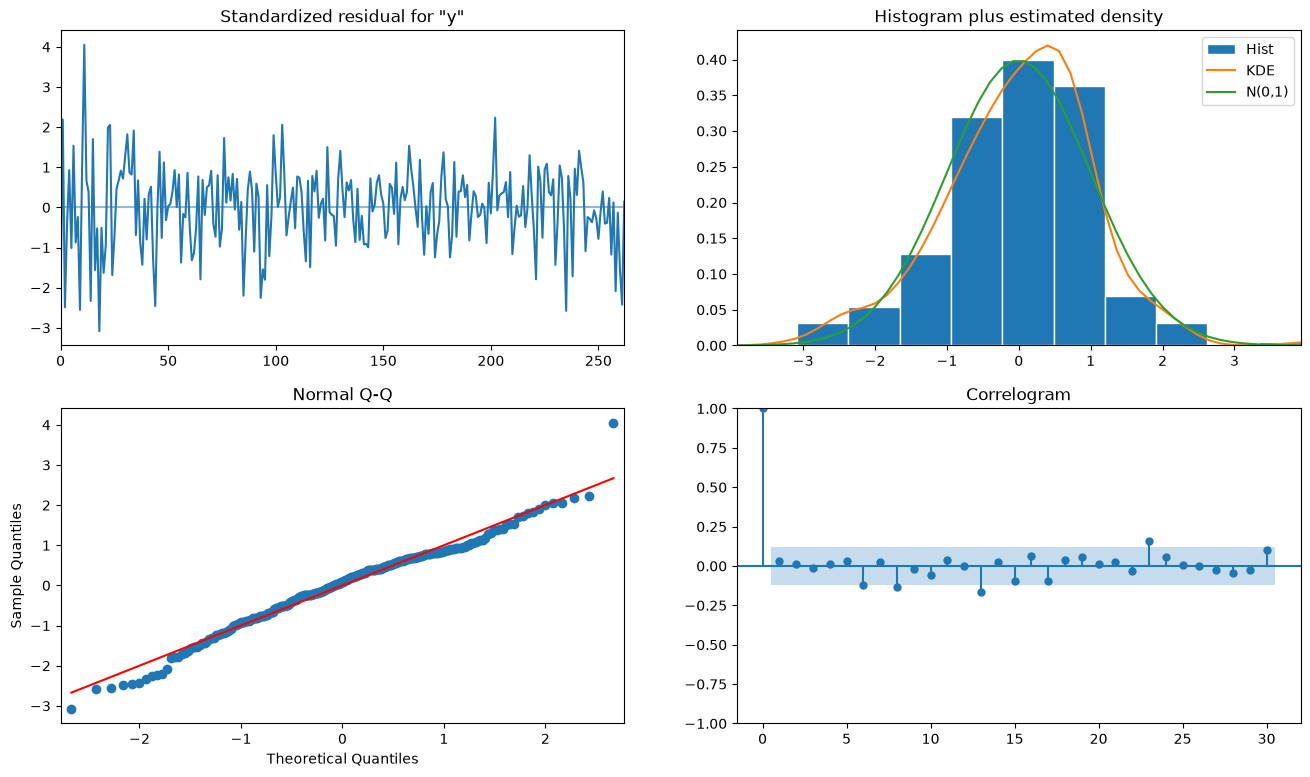

In [17]:
fig = plt.figure(figsize=(16,9))
fig = res.plot_diagnostics(fig=fig, lags=30)

(d). Regress $r_t^2$ on $r_{t-1}^2$. Interpret the estimate results.

In [18]:
df['L1_Return2'] = df['Return2'].shift(1)

df = df.dropna()

In [19]:
# testing AR(1)
results = sm.OLS(df['Return2'],sm.add_constant(df['L1_Return2'])).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                Return2   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     3999.
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          2.73e-160
Time:                        22:11:19   Log-Likelihood:                -1798.7
No. Observations:                 263   AIC:                             3601.
Df Residuals:                     261   BIC:                             3609.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.3909     22.018      1.426      0.1

(e). Fit $ARCH(1)$ to $r_t$ and discuss whether the model is appropriate by studying the auto-correlation of the error term.

### Generate Return^2

In [20]:
ARCH = arch_model(df['Return'].values, mean='AR', vol='ARCH', p=1, rescale = False).fit()

print(ARCH.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 904713.8042899866
Iteration:      2,   Func. Count:     14,   Neg. LLF: -70.94020719702989
Iteration:      3,   Func. Count:     21,   Neg. LLF: -255.6703045927628
Iteration:      4,   Func. Count:     26,   Neg. LLF: -264.8726615216559
Iteration:      5,   Func. Count:     30,   Neg. LLF: -264.872728840931
Iteration:      6,   Func. Count:     34,   Neg. LLF: -264.8727311766997
Iteration:      7,   Func. Count:     37,   Neg. LLF: -264.8727311767427
Optimization terminated successfully    (Exit mode 0)
            Current function value: -264.8727311766997
            Iterations: 7
            Function evaluations: 37
            Gradient evaluations: 7
                           AR - ARCH Model Results                            
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Li

In [21]:
forecast_arch = ARCH.forecast(horizon = 10)
print(forecast_arch.mean)
print(forecast_arch.variance)

     h.01  h.02  h.03  h.04  h.05  h.06  h.07  h.08  h.09  h.10
262  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
     h.01  h.02  h.03  h.04  h.05  h.06  h.07  h.08  h.09  h.10
262  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01


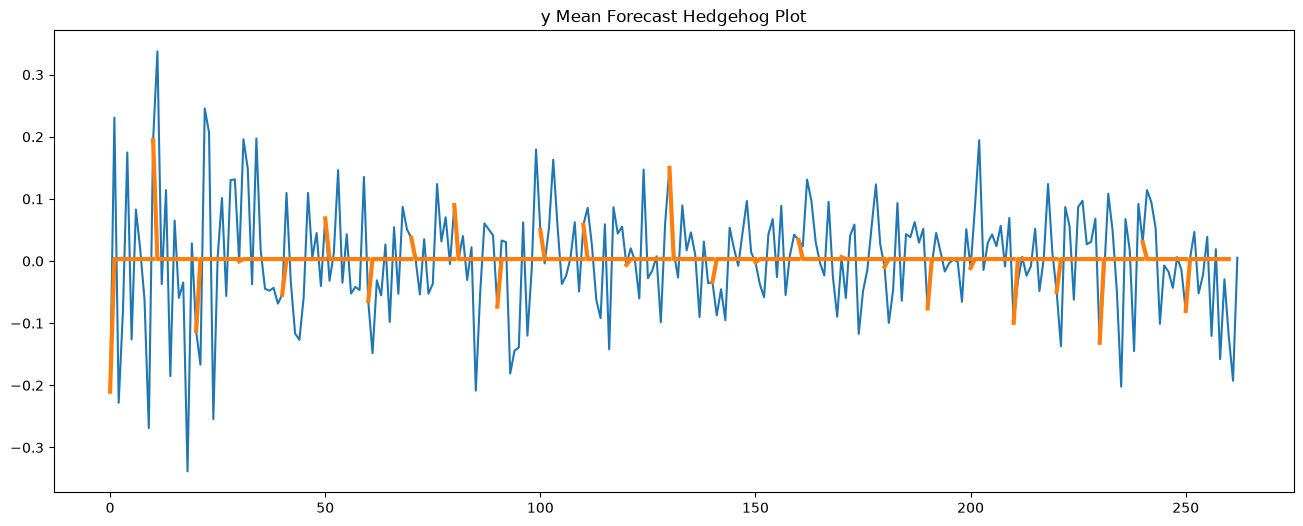

In [22]:
ARCH.hedgehog_plot(plot_type='mean', horizon = 10);

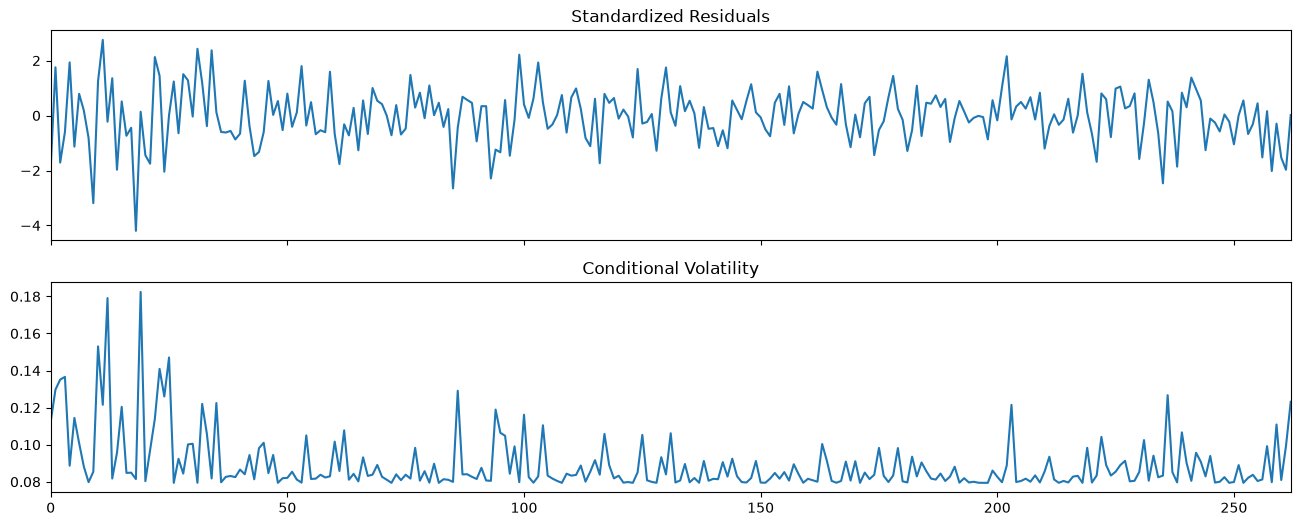

In [23]:
ARCH.plot();

(e). Fit $GARCH(1,1)$ to $r_t$ and discuss whether the model is appropriate by studying the auto-correlation of the error term.

In [24]:
GARCH = arch_model(X, mean='AR', vol='GARCH', p=1, q=1, rescale = False).fit()

print(GARCH.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 95734973955456.02
Iteration:      2,   Func. Count:     16,   Neg. LLF: 400.7074947100938
Iteration:      3,   Func. Count:     24,   Neg. LLF: -255.28109880141707
Iteration:      4,   Func. Count:     33,   Neg. LLF: -133.06953457412672
Iteration:      5,   Func. Count:     41,   Neg. LLF: -282.7272682777301
Iteration:      6,   Func. Count:     47,   Neg. LLF: -229.86416264974292
Iteration:      7,   Func. Count:     53,   Neg. LLF: -283.590569340367
Iteration:      8,   Func. Count:     58,   Neg. LLF: -283.6041018124226
Iteration:      9,   Func. Count:     63,   Neg. LLF: -283.60127862085426
Iteration:     10,   Func. Count:     69,   Neg. LLF: -283.6166583375883
Iteration:     11,   Func. Count:     74,   Neg. LLF: -283.6166953508248
Iteration:     12,   Func. Count:     79,   Neg. LLF: -283.6167005259666
Iteration:     13,   Func. Count:     83,   Neg. LLF: -283.61670052452973
Optimization terminated successfully    (Exit mod

In [25]:
forecast_garch = GARCH.forecast(horizon = 10)
print(forecast_garch.mean)
print(forecast_garch.variance)

     h.01  h.02  h.03  h.04  h.05  h.06  h.07  h.08  h.09  h.10
262  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
     h.01  h.02  h.03  h.04  h.05  h.06  h.07  h.08  h.09  h.10
262  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01


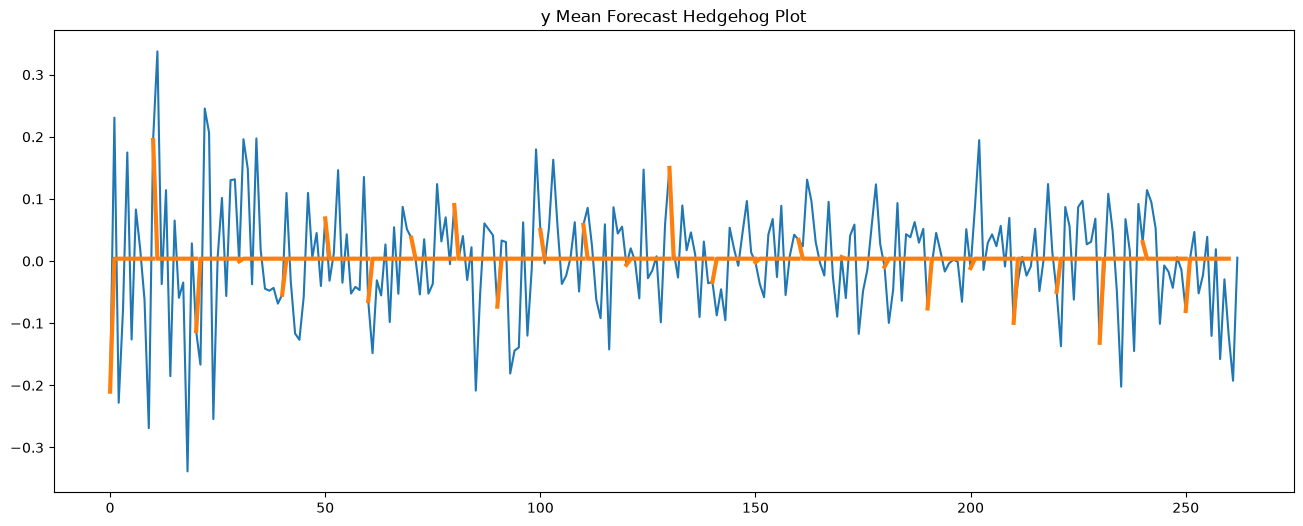

In [26]:
GARCH.hedgehog_plot(plot_type='mean', horizon = 10);

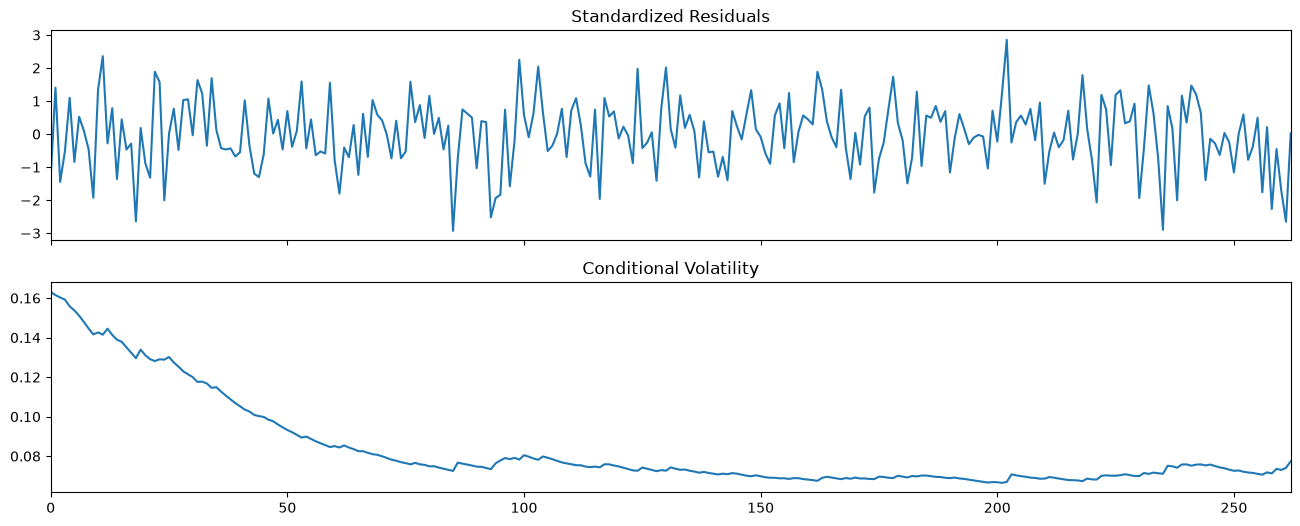

In [27]:
GARCH.plot();